In [1]:
import logging
import os
from pathlib import Path
from dotenv import load_dotenv

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import numpy as np
import pandas as pd
import category_encoders as ce 

import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Rectangle

from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
import shap

from aml.pipelines.feature_pipeline import FeaturePipeline
from aml.models.build_model import AMLEnsemble
from aml.evaluating.time_split import chronological_split, describe_split
from aml.evaluating.metrics import evaluate_binary_classifier, find_best_threshold
from aml.persistence import save_aml_ensemble, save_base_models_only

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

In [2]:
load_dotenv("../.env")
DATA_PATH = Path(os.getenv("DATA_PATH", "data")).expanduser()
CSV_PATH = DATA_PATH / "raw/AMLNet_August_2025.csv"
ROW_LIMIT = 500000
TARGET_COL = "isFraud"
SPLIT_CFG = dict(test_days=20, val_days=15, gap_days=1)
RANDOM_STATE = 42

In [3]:
raw_df = pd.read_csv(CSV_PATH, nrows=ROW_LIMIT)
target = raw_df[TARGET_COL]
raw_df = FeaturePipeline(enable_columns=True, enable_encoding=False).fit_transform(raw_df, target)
raw_df[TARGET_COL] = target

print(f"Shape: {raw_df.shape}")
print(raw_df[[TARGET_COL]].describe())
print(f"Positive rate: {raw_df[TARGET_COL].mean():.6f}")

2026-03-23 21:46:56,209 | INFO | FeaturePipeline initialized | downcasting=True | encoding=False | _scale=False | columns=True
2026-03-23 21:46:56,209 | INFO | ▶ fit_transform | in_shape=(500000, 17)
2026-03-23 21:46:56,210 | INFO | Input validated | shape=(500000, 17)
2026-03-23 21:46:56,210 | INFO | ▶ build_features | in_shape=(500000, 17)
2026-03-23 21:46:56,222 | WARNING | Dropping potential leakage columns: ['fraud_probability', 'laundering_typology', 'isFraud', 'isMoneyLaundering']
2026-03-23 21:47:22,904 | INFO | ▶ feature_engineering | in_shape=(500000, 31)
2026-03-23 21:47:22,936 | INFO | ✓ feature_engineering | out_shape=(500000, 38) | 0.032s
2026-03-23 21:47:22,937 | INFO | ▶ finalize | in_shape=(500000, 38)
2026-03-23 21:47:23,062 | INFO | ✓ finalize | out_shape=(500000, 38) | 0.125s
2026-03-23 21:47:23,084 | INFO | ✓ build_features | out_shape=(500000, 38) | 26.874s
2026-03-23 21:47:23,084 | INFO | ✓ fit_transform | out_shape=(500000, 38) | 26.875s


Shape: (500000, 39)
             isFraud
count  500000.000000
mean        0.001474
std         0.038364
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Positive rate: 0.001474


In [4]:
split = chronological_split(raw_df, timestamp_col="timestamp_ts", **SPLIT_CFG)
stats = describe_split(split, target=TARGET_COL)
print(stats)

train_df = split.train.sort_values("timestamp_ts").reset_index(drop=True)
val_df = split.val.sort_values("timestamp_ts").reset_index(drop=True)
test_df = split.test.sort_values("timestamp_ts").reset_index(drop=True)

print({k: v.shape for k, v in {" val": train_df, "val": val_df, "test": test_df}.items()})

{'train_n': 371905, 'train_pos': 538, 'train_pos_rate': 0.0014466059880883558, 'val_n': 84075, 'val_pos': 73, 'val_pos_rate': 0.0008682723758548915, 'test_n': 28286, 'test_pos': 108, 'test_pos_rate': 0.003818143251078272}
{' val': (371905, 39), 'val': (84075, 39), 'test': (28286, 39)}


In [5]:
pipe = FeaturePipeline(enable_encoding=True, enable_columns=True, alpha=20, use_logit=True)

X_train = pipe.fit_transform(train_df, train_df[TARGET_COL])
X_val = pipe.transform(val_df)
X_test = pipe.transform(test_df)

y_train = train_df[TARGET_COL].to_numpy()
y_val = val_df[TARGET_COL].to_numpy()
y_test = test_df[TARGET_COL].to_numpy()

print("Shapes | train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print(f"Train positive rate: {y_train.mean():.6f}")

2026-03-23 08:29:43,642 | INFO | FeaturePipeline initialized | downcasting=True | encoding=True | _scale=False | columns=True
2026-03-23 08:29:43,642 | INFO | ▶ fit_transform | in_shape=(371905, 39)
2026-03-23 08:29:43,643 | INFO | Input validated | shape=(371905, 39)
2026-03-23 08:29:43,643 | INFO | ▶ build_features | in_shape=(371905, 39)
2026-03-23 08:29:43,650 | WARNING | Dropping potential leakage columns: ['isFraud']
2026-03-23 08:29:43,840 | INFO | ▶ feature_engineering | in_shape=(371905, 38)
2026-03-23 08:29:43,847 | INFO | ✓ feature_engineering | out_shape=(371905, 38) | 0.006s
2026-03-23 08:29:43,847 | INFO | ▶ finalize | in_shape=(371905, 38)
2026-03-23 08:29:43,922 | INFO | ✓ finalize | out_shape=(371905, 38) | 0.075s
2026-03-23 08:29:43,925 | INFO | ✓ build_features | out_shape=(371905, 38) | 0.281s
2026-03-23 08:29:43,925 | INFO | ▶ fit_encoder | in_shape=(371905, 38)
2026-03-23 08:29:49,750 | WARNING | get_feature_names_out() exists but failed, fallback to manual build


Shapes | train/val/test: (371905, 69) (84075, 69) (28286, 69)
Train positive rate: 0.001447


In [8]:
N_pos = (y_train == 1).sum()
N_neg = (y_train == 0).sum()

scale_pos_weight = N_neg / N_pos

In [9]:
X_train_not_encoded = train_df.drop(columns="isFraud")
y_train_not_encoded = train_df.isFraud

X_val_not_encoded = val_df.drop(columns="isFraud")
y_val_not_encoded = val_df.isFraud

X_test_not_encoded = test_df.drop(columns="isFraud")
y_test_not_encoded = test_df.isFraud

In [10]:
cat = CatBoostClassifier(
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=200,
    random_state=42,
    verbose=100,
    has_time=True
)

print("START FITTING")

result = []

cat.fit(X_train_not_encoded, y_train_not_encoded,
        eval_set=(X_val_not_encoded, y_val_not_encoded),
        cat_features=np.array(train_df.columns[(train_df.dtypes=="category") | (train_df.dtypes=="object")]),
)
metrics = evaluate_binary_classifier(cat, X_test_not_encoded, y_test_not_encoded, threshold=0.5)

result.append({
    "model": "no_encoding",
    "roc_auc": metrics["roc_auc"],
    "pr_auc": metrics["pr_auc"],
    "f1_05": metrics["f1"],
})
print("no_encoder ended with")

cat.fit(X_train, y_train,
        eval_set=(X_val, y_val),
)
metrics = evaluate_binary_classifier(cat, X_test, y_test, threshold=0.5)

result.append({
    "model": "encoding",
    "roc_auc": metrics["roc_auc"],
    "pr_auc": metrics["pr_auc"],
    "f1_05": metrics["f1"],
})
print("encoder ended with")

pd.DataFrame(result).sort_values(by="pr_auc", ascending=False)

START FITTING
Learning rate set to 0.136712
0:	test: 0.9438448	best: 0.9438448 (0)	total: 245ms	remaining: 4m 5s
100:	test: 0.9985462	best: 0.9991114 (51)	total: 14.1s	remaining: 2m 5s
200:	test: 0.9985247	best: 0.9991114 (51)	total: 21.4s	remaining: 1m 25s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9991114041
bestIteration = 51

Shrink model to first 52 iterations.
no_encoder ended with
Learning rate set to 0.136712
0:	test: 0.8886243	best: 0.8886243 (0)	total: 18.7ms	remaining: 18.6s
100:	test: 0.9932306	best: 0.9964727 (9)	total: 1.56s	remaining: 13.9s
200:	test: 0.9932317	best: 0.9964727 (9)	total: 2.97s	remaining: 11.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9964726867
bestIteration = 9

Shrink model to first 10 iterations.
encoder ended with


,model,roc_auc,pr_auc,f1_05
0,no_encoding,0.996921,0.889253,0.808163
1,encoding,0.970734,0.501413,0.439024


In [ ]:
base_models = {
    "xg": XGBClassifier(
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        early_stopping_rounds=200,
        random_state=42,
        use_label_encoder=False,
        verbosity=0
    ),
    "cat": CatBoostClassifier(
        eval_metric="PRAUC",
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=200,
        random_state=42,
        has_time=True,
        verbose=False
    ),
    "ligh": LGBMClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
        verbose=-1
    ),
}

In [ ]:
result = []
feature_importances = {}
fi_perm = {}
shap_df = {}

for name, model in base_models.items():
    print("Fitting", name)
    fit_params = {
        "X": X_train,
        "y": y_train,
        "eval_set": [(X_val, y_val)]
    }
    if name == "xg":
        fit_params["verbose"] = False
    model.fit(**fit_params)

    # Basic metrics
    metrics = evaluate_binary_classifier(model, X_test, y_test, threshold=0.5)

    result.append({
        "model": name,
        "roc_auc": metrics["roc_auc"],
        "recall_curve": metrics["recall_curve"],
        "pr_auc": metrics["pr_auc"],
        "f1_05": metrics["f1"],
    })

    # Feature importance
    if name == "cat":
        fi = model.get_feature_importance()
    else:
        fi = model.feature_importances_

    feature_importances[name] = (
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": fi
        })
        .sort_values(by="importance", ascending=False)
        .reset_index(drop=True)
    )

    # Permutation importance 
    r = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    fi_perm[name] = (
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": r.importances_mean
        })
        .sort_values(by="importance", ascending=False)
        .reset_index(drop=True)
    )

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_df[name] = pd.DataFrame(
        shap_values,
        columns=X_test.columns,
        index=X_test.index
    )

val_df = pd.DataFrame(result).sort_values("pr_auc", ascending=False).reset_index(drop=True)
val_df

# Optuna

In [11]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS    = 50   # ↑ for production; 50 is fast enough for a demo
TIMEOUT_SEC = None  # set e.g. 600 to cap wall-time per study

def _pr_auc(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    return average_precision_score(y, proba)


In [12]:
def xgb_objective(trial):
    params = dict(
        n_estimators        = trial.suggest_int("n_estimators", 300, 2000, step=100),
        max_depth           = trial.suggest_int("max_depth", 3, 10),
        learning_rate       = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        subsample           = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree    = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight    = trial.suggest_int("min_child_weight", 1, 20),
        reg_alpha           = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda          = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        gamma               = trial.suggest_float("gamma", 0.0, 5.0),
        scale_pos_weight    = scale_pos_weight,
        eval_metric         = "aucpr",
        early_stopping_rounds = 50,
        use_label_encoder   = False,
        random_state        = RANDOM_STATE,
        n_jobs              = -1,
        verbosity           = 0,
    )
    model = XGBClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
    return _pr_auc(model, X_val, y_val)

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    study_name="xgb_study",
)
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, timeout=TIMEOUT_SEC, show_progress_bar=True)

print(f"[XGB]  Best PR-AUC: {xgb_study.best_value:.5f}")
print(f"[XGB]  Best params: {xgb_study.best_params}")


  0%|          | 0/50 [00:00<?, ?it/s]

[XGB]  Best PR-AUC: 0.81666
[XGB]  Best params: {'n_estimators': 1600, 'max_depth': 9, 'learning_rate': 0.013131066043702478, 'subsample': 0.9164087998653863, 'colsample_bytree': 0.40021681191897374, 'min_child_weight': 11, 'reg_alpha': 0.0035836440263247627, 'reg_lambda': 0.00023816261259639122, 'gamma': 4.717945419579882}


In [13]:
def lgbm_objective(trial):
    params = dict(
        n_estimators        = trial.suggest_int("n_estimators", 300, 2000, step=100),
        max_depth           = trial.suggest_int("max_depth", 3, 12),
        learning_rate       = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        num_leaves          = trial.suggest_int("num_leaves", 20, 300),
        subsample           = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree    = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_samples   = trial.suggest_int("min_child_samples", 5, 100),
        reg_alpha           = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda          = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        class_weight        = "balanced",
        random_state        = RANDOM_STATE,
        n_jobs              = -1,
        verbose             = -1,
    )
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[
                  __import__("lightgbm").early_stopping(50, verbose=False),
                  __import__("lightgbm").log_evaluation(-1),
              ])
    return _pr_auc(model, X_val, y_val)

lgbm_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    study_name="lgbm_study",
)
lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, timeout=TIMEOUT_SEC, show_progress_bar=True)

print(f"[LGBM] Best PR-AUC: {lgbm_study.best_value:.5f}")
print(f"[LGBM] Best params: {lgbm_study.best_params}")


  0%|          | 0/50 [00:00<?, ?it/s]

[LGBM] Best PR-AUC: 0.91339
[LGBM] Best params: {'n_estimators': 300, 'max_depth': 11, 'learning_rate': 0.2601519903948713, 'num_leaves': 210, 'subsample': 0.8638128246408215, 'colsample_bytree': 0.41992513458798153, 'min_child_samples': 58, 'reg_alpha': 1.3087335683219211e-07, 'reg_lambda': 0.03700263788172329}


In [14]:
def catboost_objective(trial):
    params = dict(
        iterations          = trial.suggest_int("iterations", 300, 2000, step=100),
        depth               = trial.suggest_int("depth", 3, 10),
        learning_rate       = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        l2_leaf_reg         = trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        border_count        = trial.suggest_int("border_count", 32, 255),
        bagging_temperature = trial.suggest_float("bagging_temperature", 0.0, 1.0),
        random_strength     = trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        scale_pos_weight    = scale_pos_weight,
        eval_metric         = "PRAUC",
        early_stopping_rounds = 50,
        random_state        = RANDOM_STATE,
        has_time            = True,
        verbose             = False,
    )
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=(X_val, y_val))
    return _pr_auc(model, X_val, y_val)

cat_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    study_name="cat_study",
)
cat_study.optimize(catboost_objective, n_trials=N_TRIALS, timeout=TIMEOUT_SEC, show_progress_bar=True)

print(f"[CAT]  Best PR-AUC: {cat_study.best_value:.5f}")
print(f"[CAT]  Best params: {cat_study.best_params}")


  0%|          | 0/50 [00:00<?, ?it/s]

[CAT]  Best PR-AUC: 0.86211
[CAT]  Best params: {'iterations': 1000, 'depth': 9, 'learning_rate': 0.1105496296151553, 'l2_leaf_reg': 0.06507187656499241, 'border_count': 211, 'bagging_temperature': 0.620738939230913, 'random_strength': 6.704011261128742}


In [15]:
# ── Rebuild best models with full best-params ──────────────────────────────

best_xgb = XGBClassifier(
    **xgb_study.best_params,
    scale_pos_weight    = scale_pos_weight,
    eval_metric         = "aucpr",
    early_stopping_rounds = 50,
    use_label_encoder   = False,
    random_state        = RANDOM_STATE,
    n_jobs              = -1,
    verbosity           = 0,
)
best_xgb.fit(X_train, y_train,
             eval_set=[(X_val, y_val)], verbose=False)

import lightgbm as lgb

best_lgbm = LGBMClassifier(
    **lgbm_study.best_params,
    class_weight = "balanced",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbose      = -1,
)
best_lgbm.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[
                  lgb.early_stopping(50, verbose=False),
                  lgb.log_evaluation(-1),
              ])

best_cat = CatBoostClassifier(
    **cat_study.best_params,
    scale_pos_weight    = scale_pos_weight,
    eval_metric         = "PRAUC",
    early_stopping_rounds = 50,
    random_state        = RANDOM_STATE,
    has_time            = True,
    verbose             = False,
)
best_cat.fit(X_train, y_train,
             eval_set=(X_val, y_val))

# ── Quick val-set comparison ─────────────────────────────────────────────────
tuning_results = []
for name, model in [("xgb_tuned", best_xgb), ("lgbm_tuned", best_lgbm), ("cat_tuned", best_cat)]:
    metrics = evaluate_binary_classifier(model, X_test, y_test, threshold=0.5)
    tuning_results.append({
        "model":   name,
        "roc_auc": metrics["roc_auc"],
        "pr_auc":  metrics["pr_auc"],
        "f1_05":   metrics["f1"],
    })

pd.DataFrame(tuning_results).sort_values("pr_auc", ascending=False)


,model,roc_auc,pr_auc,f1_05
1,lgbm_tuned,0.994775,0.900989,0.513514
0,xgb_tuned,0.977975,0.831133,0.364964
2,cat_tuned,0.995706,0.826726,0.567742


## Stacking

In [16]:
from sklearn.model_selection import TimeSeriesSplit

N_META_SPLITS = 5   # number of folds for OOF generation

# Concatenate train + val for OOF generation (keep temporal order)
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval  = np.concatenate([y_train, y_val])

n_trainval  = len(X_trainval)
tscv        = TimeSeriesSplit(n_splits=N_META_SPLITS)

# Containers: one OOF probability column per base learner
oof_meta = np.zeros((n_trainval, 3), dtype=np.float64)   # [xgb, lgbm, cat]
oof_cols = ["xgb_prob", "lgbm_prob", "cat_prob"]

import lightgbm as lgb

for fold_idx, (tr_idx, vl_idx) in enumerate(tscv.split(X_trainval)):
    print(f"  Fold {fold_idx + 1}/{N_META_SPLITS}  |  "
          f"train={len(tr_idx):,}  val={len(vl_idx):,}")

    Xf_tr, yf_tr = X_trainval.iloc[tr_idx], y_trainval[tr_idx]
    Xf_vl, yf_vl = X_trainval.iloc[vl_idx], y_trainval[vl_idx]

    # ── XGBoost ──────────────────────────────────────────────────────────────
    m_xgb = XGBClassifier(
        **xgb_study.best_params,
        scale_pos_weight    = scale_pos_weight,
        eval_metric         = "aucpr",
        early_stopping_rounds = 30,
        use_label_encoder   = False,
        random_state        = RANDOM_STATE,
        n_jobs              = -1,
        verbosity           = 0,
    )
    m_xgb.fit(Xf_tr, yf_tr, eval_set=[(Xf_vl, yf_vl)], verbose=False)
    oof_meta[vl_idx, 0] = m_xgb.predict_proba(Xf_vl)[:, 1]

    # ── LightGBM ──────────────────────────────────────────────────────────────
    m_lgbm = LGBMClassifier(
        **lgbm_study.best_params,
        class_weight = "balanced",
        random_state = RANDOM_STATE,
        n_jobs       = -1,
        verbose      = -1,
    )
    m_lgbm.fit(Xf_tr, yf_tr,
               eval_set=[(Xf_vl, yf_vl)],
               callbacks=[
                   lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(-1),
               ])
    oof_meta[vl_idx, 1] = m_lgbm.predict_proba(Xf_vl)[:, 1]

    # ── CatBoost ──────────────────────────────────────────────────────────────
    m_cat = CatBoostClassifier(
        **cat_study.best_params,
        scale_pos_weight    = scale_pos_weight,
        eval_metric         = "PRAUC",
        early_stopping_rounds = 30,
        random_state        = RANDOM_STATE,
        has_time            = True,
        verbose             = False,
    )
    m_cat.fit(Xf_tr, yf_tr, eval_set=(Xf_vl, yf_vl))
    oof_meta[vl_idx, 2] = m_cat.predict_proba(Xf_vl)[:, 1]

oof_meta_df = pd.DataFrame(oof_meta, columns=oof_cols)
print("\nOOF meta-features shape:", oof_meta_df.shape)
print(f"OOF XGB   PR-AUC: {average_precision_score(y_trainval, oof_meta[:, 0]):.5f}")
print(f"OOF LGBM  PR-AUC: {average_precision_score(y_trainval, oof_meta[:, 1]):.5f}")
print(f"OOF CAT   PR-AUC: {average_precision_score(y_trainval, oof_meta[:, 2]):.5f}")


  Fold 1/5  |  train=76,000  val=75,996
  Fold 2/5  |  train=151,996  val=75,996
  Fold 3/5  |  train=227,992  val=75,996
  Fold 4/5  |  train=303,988  val=75,996
  Fold 5/5  |  train=379,984  val=75,996

OOF meta-features shape: (455980, 3)
OOF XGB   PR-AUC: 0.52752
OOF LGBM  PR-AUC: 0.87911
OOF CAT   PR-AUC: 0.85129


In [17]:
# Generate test-set meta-features from the fully-tuned base learners
test_meta = np.column_stack([
    best_xgb.predict_proba(X_test)[:, 1],
    best_lgbm.predict_proba(X_test)[:, 1],
    best_cat.predict_proba(X_test)[:, 1],
])
test_meta_df = pd.DataFrame(test_meta, columns=oof_cols)
print("Test meta-features shape:", test_meta_df.shape)


Test meta-features shape: (28286, 3)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline

meta_learner = SkPipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C             = 1.0,
        class_weight  = "balanced",
        solver        = "lbfgs",
        max_iter      = 1000,
        random_state  = RANDOM_STATE,
    )),
])

meta_learner.fit(oof_meta_df, y_trainval)
print("Meta-learner coefficients (xgb / lgbm / cat):",
      meta_learner.named_steps["lr"].coef_[0].round(4))


Meta-learner coefficients (xgb / lgbm / cat): [-1.549   9.9154  0.9807]


/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


In [ ]:
# ── Stacking test-set evaluation ─────────────────────────────────────────────
stack_proba = meta_learner.predict_proba(test_meta_df)[:, 1]
stack_pr_auc  = average_precision_score(y_test, stack_proba)
stack_roc_auc = __import__("sklearn.metrics", fromlist=["roc_auc_score"]).roc_auc_score(y_test, stack_proba)

from sklearn.metrics import f1_score
best_thresh, _ = find_best_threshold(y_test, stack_proba)
stack_f1 = f1_score(y_test, (stack_proba >= best_thresh).astype(int))

# ── Combine all results ───────────────────────────────────────────────────────
all_results = tuning_results + [{
    "model":   "stacking (lr meta)",
    "roc_auc": stack_roc_auc,
    "pr_auc":  stack_pr_auc,
    "f1_05":   stack_f1,
}]

results_df = pd.DataFrame(all_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
results_df.style.highlight_max(subset=["roc_auc", "pr_auc", "f1_05"], color="green").highlight_min(subset=["roc_auc", "pr_auc", "f1_05"], color="red")


/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,model,roc_auc,pr_auc,f1_05
0,lgbm_tuned,0.994775,0.900989,0.513514
1,stacking (lr meta),0.963183,0.877022,0.878924
2,xgb_tuned,0.977975,0.831133,0.364964
3,cat_tuned,0.995706,0.826726,0.567742


In [26]:
results_df.style.highlight_max(subset=["roc_auc", "pr_auc", "f1_05"], color="green").highlight_min(subset=["roc_auc", "pr_auc", "f1_05"], color="red")

,model,roc_auc,pr_auc,f1_05
0,lgbm_tuned,0.998039,0.933475,0.888889
1,xgb_tuned,0.998780,0.931566,0.913462
2,cat_tuned,0.988092,0.911421,0.907317
3,stacking_lr_clean,0.998105,0.895991,0.912621


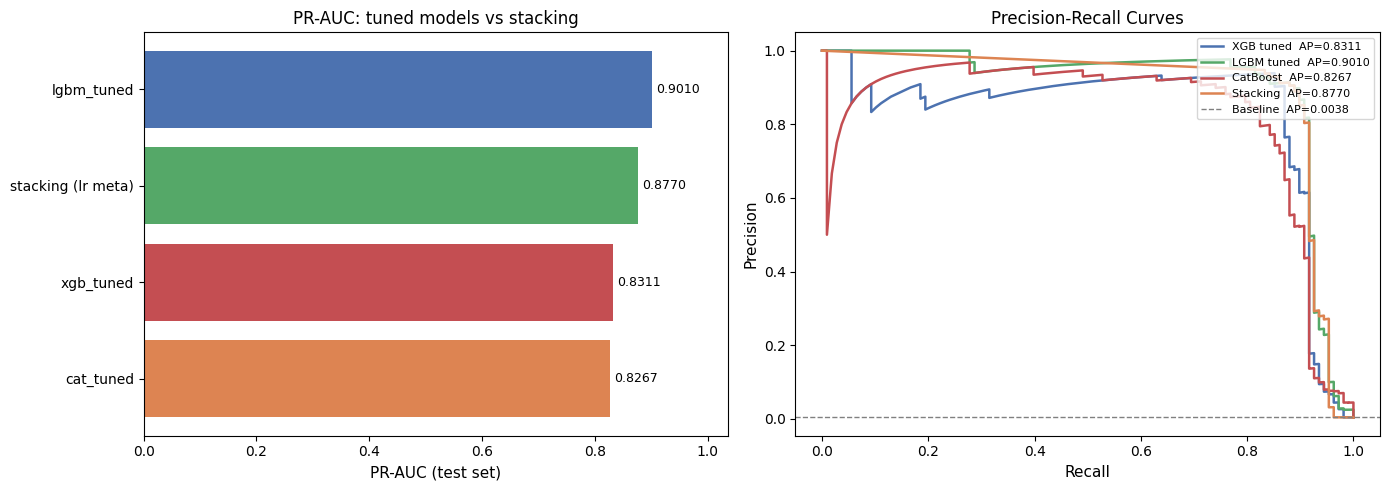

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── PR-AUC bar chart ─────────────────────────────────────────────────────────
ax = axes[0]
colors = ["#4C72B0", "#55A868", "#C44E52", "#DD8452"]
bars = ax.barh(results_df["model"], results_df["pr_auc"], color=colors[:len(results_df)])
ax.set_xlabel("PR-AUC (test set)", fontsize=11)
ax.set_title("PR-AUC: tuned models vs stacking", fontsize=12)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_xlim(0, results_df["pr_auc"].max() * 1.15)
ax.invert_yaxis()

# ── Precision-Recall curves ───────────────────────────────────────────────────
ax2 = axes[1]
models_to_plot = {
    "XGB tuned":   best_xgb.predict_proba(X_test)[:, 1],
    "LGBM tuned":  best_lgbm.predict_proba(X_test)[:, 1],
    "CatBoost":    best_cat.predict_proba(X_test)[:, 1],
    "Stacking":    stack_proba,
}

for (label, proba), color in zip(models_to_plot.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax2.plot(rec, prec, label=f"{label}  AP={ap:.4f}", color=color, lw=1.8)

baseline = y_test.mean()
ax2.axhline(baseline, ls="--", color="grey", lw=1, label=f"Baseline  AP={baseline:.4f}")
ax2.set_xlabel("Recall", fontsize=11)
ax2.set_ylabel("Precision", fontsize=11)
ax2.set_title("Precision-Recall Curves", fontsize=12)
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("stacking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd

from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
)

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
N_TRIALS = 50
META_SPLITS = 5
RANDOM_STATE = 42

optuna.logging.set_verbosity(optuna.logging.WARNING)

# scale_pos_weight должен уже быть у тебя рассчитан выше
# scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def pr_auc_score(y_true, proba):
    return average_precision_score(y_true, proba)

def evaluate_binary(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, pred, zero_division=0),
    }

def best_f1_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return 0.5

    f1 = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best_idx = np.nanargmax(f1)
    return float(thresholds[best_idx])

# --------------------------------------------------
# MODEL FACTORY
# --------------------------------------------------
def build_model(name, params, scale_pos_weight, early_stopping_rounds=50):
    if name == "xgb":
        return XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            early_stopping_rounds=early_stopping_rounds,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )

    if name == "lgbm":
        return LGBMClassifier(
            **params,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

    if name == "cat":
        return CatBoostClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="PRAUC",
            early_stopping_rounds=early_stopping_rounds,
            random_state=RANDOM_STATE,
            has_time=True,
            verbose=False,
            allow_writing_files=False,
        )

    raise ValueError(f"Unknown model: {name}")

def fit_model(name, model, X_tr, y_tr, X_va, y_va):
    if name == "xgb":
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        return model

    if name == "lgbm":
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )
        return model

    if name == "cat":
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va))
        return model

    raise ValueError(f"Unknown model: {name}")

# --------------------------------------------------
# OPTUNA SEARCH SPACES
# --------------------------------------------------
def suggest_params(trial, name):
    if name == "xgb":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 300, 2000, step=100),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        }

    if name == "lgbm":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 300, 2000, step=100),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 20, 300),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        }

    if name == "cat":
        return {
            "iterations": trial.suggest_int("iterations", 300, 2000, step=100),
            "depth": trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
            "border_count": trial.suggest_int("border_count", 32, 255),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        }

    raise ValueError(f"Unknown model: {name}")

# --------------------------------------------------
# OPTUNA OBJECTIVE: train -> val
# --------------------------------------------------
def make_objective(name):
    def objective(trial):
        params = suggest_params(trial, name)
        model = build_model(
            name=name,
            params=params,
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=50,
        )
        model = fit_model(name, model, X_train, y_train, X_val, y_val)
        val_proba = model.predict_proba(X_val)[:, 1]
        return pr_auc_score(y_val, val_proba)
    return objective

def tune_model(name, n_trials=N_TRIALS):
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
        study_name=f"{name}_study",
    )
    study.optimize(make_objective(name), n_trials=n_trials, show_progress_bar=True)
    return study

# --------------------------------------------------
# 1) TUNE BASE MODELS
# --------------------------------------------------
studies = {}
best_params = {}

for name in ["xgb", "lgbm", "cat"]:
    print(f"Tuning {name} ...")
    study = tune_model(name, n_trials=N_TRIALS)
    studies[name] = study
    best_params[name] = study.best_params
    print(f"{name} best PR-AUC on val: {study.best_value:.6f}")
    print(best_params[name])
    print("-" * 60)

# --------------------------------------------------
# 2) FIT BASE MODELS ON TRAIN ONLY
#    (for honest val-meta and OOF-meta generation)
# --------------------------------------------------
base_models_train = {}

for name in ["xgb", "lgbm", "cat"]:
    model = build_model(
        name=name,
        params=best_params[name],
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=50,
    )
    model = fit_model(name, model, X_train, y_train, X_val, y_val)
    base_models_train[name] = model

# --------------------------------------------------
# 3) EVALUATE BASE MODELS ON TEST
#    using model trained on train+val later
# --------------------------------------------------
# Сначала честно строим OOF на train для meta-learner.
# val сюда НЕ подмешиваем.
# --------------------------------------------------
def make_oof_meta_features(X, y, best_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    model_names = ["xgb", "lgbm", "cat"]

    oof = np.full((len(X), len(model_names)), np.nan, dtype=np.float64)

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X), 1):
        print(f"OOF fold {fold}/{n_splits} | train={len(tr_idx):,} val={len(va_idx):,}")

        X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
        X_va, y_va = X.iloc[va_idx], y[va_idx]

        for col_idx, name in enumerate(model_names):
            fold_model = build_model(
                name=name,
                params=best_params[name],
                scale_pos_weight=scale_pos_weight,
                early_stopping_rounds=30,
            )
            fold_model = fit_model(name, fold_model, X_tr, y_tr, X_va, y_va)
            oof[va_idx, col_idx] = fold_model.predict_proba(X_va)[:, 1]

    valid_mask = ~np.isnan(oof).any(axis=1)
    oof_df = pd.DataFrame(
        oof[valid_mask],
        columns=["xgb_prob", "lgbm_prob", "cat_prob"],
    )
    y_oof = y[valid_mask]
    return oof_df, y_oof

oof_meta_df, y_oof = make_oof_meta_features(
    X_train.reset_index(drop=True),
    y_train,
    best_params=best_params,
    n_splits=META_SPLITS,
)

print("OOF meta shape:", oof_meta_df.shape)

# --------------------------------------------------
# 4) TRAIN META-LEARNER ON OOF(TRAIN ONLY)
# --------------------------------------------------
meta_learner = SkPipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

meta_learner.fit(oof_meta_df, y_oof)

print(
    "Meta coefficients:",
    meta_learner.named_steps["lr"].coef_[0].round(4)
)

# --------------------------------------------------
# 5) BUILD META FEATURES FOR VAL
#    using base models trained on train only
# --------------------------------------------------
val_meta_df = pd.DataFrame({
    "xgb_prob": base_models_train["xgb"].predict_proba(X_val)[:, 1],
    "lgbm_prob": base_models_train["lgbm"].predict_proba(X_val)[:, 1],
    "cat_prob": base_models_train["cat"].predict_proba(X_val)[:, 1],
})

val_stack_proba = meta_learner.predict_proba(val_meta_df)[:, 1]
best_stack_threshold = best_f1_threshold(y_val, val_stack_proba)

print(f"Best stack threshold from val: {best_stack_threshold:.6f}")

# --------------------------------------------------
# 6) REFIT BASE MODELS ON TRAIN+VAL
#    for final TEST inference only
# --------------------------------------------------
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = np.concatenate([y_train, y_val])

base_models_trainval = {}

for name in ["xgb", "lgbm", "cat"]:
    # Используем вал в качестве eval_set нельзя — test трогать нельзя.
    # Поэтому обучаем на train+val без external holdout.
    # Для моделей с большим n_estimators/iterations лучше можно поставить
    # n_estimators/iterations = best_iteration из первой fit-версии,
    # но здесь оставляем как есть для простоты.
    params = best_params[name].copy()

    if name == "xgb":
        model = XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
        model.fit(X_trainval, y_trainval, verbose=False)

    elif name == "lgbm":
        model = LGBMClassifier(
            **params,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(X_trainval, y_trainval)

    elif name == "cat":
        model = CatBoostClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="PRAUC",
            random_state=RANDOM_STATE,
            has_time=True,
            verbose=False,
            allow_writing_files=False,
        )
        model.fit(X_trainval, y_trainval)

    base_models_trainval[name] = model

# --------------------------------------------------
# 7) FINAL TEST EVALUATION
# --------------------------------------------------
test_meta_df = pd.DataFrame({
    "xgb_prob": base_models_trainval["xgb"].predict_proba(X_test)[:, 1],
    "lgbm_prob": base_models_trainval["lgbm"].predict_proba(X_test)[:, 1],
    "cat_prob": base_models_trainval["cat"].predict_proba(X_test)[:, 1],
})

stack_test_proba = meta_learner.predict_proba(test_meta_df)[:, 1]

# base model scores on test
results = []
for name in ["xgb", "lgbm", "cat"]:
    proba = base_models_trainval[name].predict_proba(X_test)[:, 1]
    m = evaluate_binary(y_test, proba, threshold=0.5)
    results.append({
        "model": f"{name}_tuned",
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"],
        "f1_05": m["f1"],
    })

# stacking score on test, threshold fixed from val
stack_metrics = evaluate_binary(y_test, stack_test_proba, threshold=best_stack_threshold)
results.append({
    "model": "stacking_lr_clean",
    "roc_auc": stack_metrics["roc_auc"],
    "pr_auc": stack_metrics["pr_auc"],
    "f1_05": stack_metrics["f1"],
})

results_df = (
    pd.DataFrame(results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

results_df.style.highlight_max(subset=["roc_auc", "pr_auc", "f1_05"], color="green").highlight_min(subset=["roc_auc", "pr_auc", "f1_05"], color="red")

Tuning xgb ...


  0%|          | 0/50 [00:00<?, ?it/s]

xgb best PR-AUC on val: 0.816662
{'n_estimators': 1600, 'max_depth': 9, 'learning_rate': 0.013131066043702478, 'subsample': 0.9164087998653863, 'colsample_bytree': 0.40021681191897374, 'min_child_weight': 11, 'reg_alpha': 0.0035836440263247627, 'reg_lambda': 0.00023816261259639122, 'gamma': 4.717945419579882}
------------------------------------------------------------
Tuning lgbm ...


  0%|          | 0/50 [00:00<?, ?it/s]

lgbm best PR-AUC on val: 0.913390
{'n_estimators': 300, 'max_depth': 11, 'learning_rate': 0.2601519903948713, 'num_leaves': 210, 'subsample': 0.8638128246408215, 'colsample_bytree': 0.41992513458798153, 'min_child_samples': 58, 'reg_alpha': 1.3087335683219211e-07, 'reg_lambda': 0.03700263788172329}
------------------------------------------------------------
Tuning cat ...


  0%|          | 0/50 [00:00<?, ?it/s]

cat best PR-AUC on val: 0.862113
{'iterations': 1000, 'depth': 9, 'learning_rate': 0.1105496296151553, 'l2_leaf_reg': 0.06507187656499241, 'border_count': 211, 'bagging_temperature': 0.620738939230913, 'random_strength': 6.704011261128742}
------------------------------------------------------------
OOF fold 1/5 | train=61,985 val=61,984
OOF fold 2/5 | train=123,969 val=61,984
OOF fold 3/5 | train=185,953 val=61,984
OOF fold 4/5 | train=247,937 val=61,984
OOF fold 5/5 | train=309,921 val=61,984
OOF meta shape: (309920, 3)
Meta coefficients: [2.41000e-02 3.09891e+01 2.73500e-01]
Best stack threshold from val: 1.000000


/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/skl

,model,roc_auc,pr_auc,f1_05
0,lgbm_tuned,0.998039,0.933475,0.888889
1,xgb_tuned,0.998780,0.931566,0.913462
2,cat_tuned,0.988092,0.911421,0.907317
3,stacking_lr_clean,0.998105,0.895991,0.912621


In [28]:
results_df.style.highlight_max(subset=["roc_auc", "pr_auc", "f1_05"], color="green").highlight_min(subset=["roc_auc", "pr_auc", "f1_05"], color="red")

,model,roc_auc,pr_auc,f1_05
0,lgbm_tuned,0.998039,0.933475,0.888889
1,xgb_tuned,0.998780,0.931566,0.913462
2,cat_tuned,0.988092,0.911421,0.907317
3,stacking_lr_clean,0.998105,0.895991,0.912621
